In [1]:
from pathlib import Path

from main import MAE

from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

from skimage import io

import pandas as pd

/proj/berzelius-2025-315/users/x_dilwi/conda_envs/h5env_clean_py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


n_channels: 8 mean shape: (8,)
Names dtype: object shape: (87,)
Example raw: b'BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component_data_y00000_x01536' type: <class 'bytes'>
sample tensor shape: torch.Size([8, 256, 256]) name: BOMI2_TIL_1_Core[1,1,A]_[5091,35249]_component_data_y00000_x01536


In [2]:
import torch

In [3]:
import importlib, attention_map_things
importlib.reload(attention_map_things)

<module 'attention_map_things' from '/proj/berzelius-2025-315/users/x_dilwi/SSL-Multiplexed-Imaging/level_1_code/MAE_Lightly/attention_map_things.py'>

In [4]:
import seaborn as sns

## Load the model

Pre-trained model

In [5]:
model_path = '/proj/berzelius-2025-315/users/x_dilwi/MAE_Lightly_runs/run1/last.ckpt'
model = MAE.load_from_checkpoint(model_path, map_location='cpu')
model.eval()
backbone = model.backbone
backbone = backbone.to("cpu")

 ## Open roi image

In [6]:
tif_path = "/proj/berzelius-2025-315/users/x_dilwi/full_cores/BOMI2_TIL_1_Core[1,2,D]_[10473,37043]_component_data.tif"  # <- your full core tif

image = io.imread(tif_path)  # could be (C,H,W) or (H,W,C)
image = np.array(image)

# ensure channels-first (C,H,W)
if image.ndim == 3 and image.shape[0] > 32:   # likely (H,W,C)
    image = np.transpose(image, (2, 0, 1))
elif image.ndim == 2:
    image = image[None, ...]

image = image.astype(np.float32, copy=False)

print(image.shape)  # should be (8, H, W)

(8, 2808, 3752)


In [7]:
@dataclass
class dummy_dataclass:
    input_size = 224
    overlap = 112
    dataset = 'BOMI' # Dataset name
    data_path = '' # Datapath
args = dummy_dataclass()

In [8]:
marker_names = ["DAPI","CD4","CD20","CD8","FoxP3","CD45RO","PanCK","Autofluorescence"]

Visualize channels

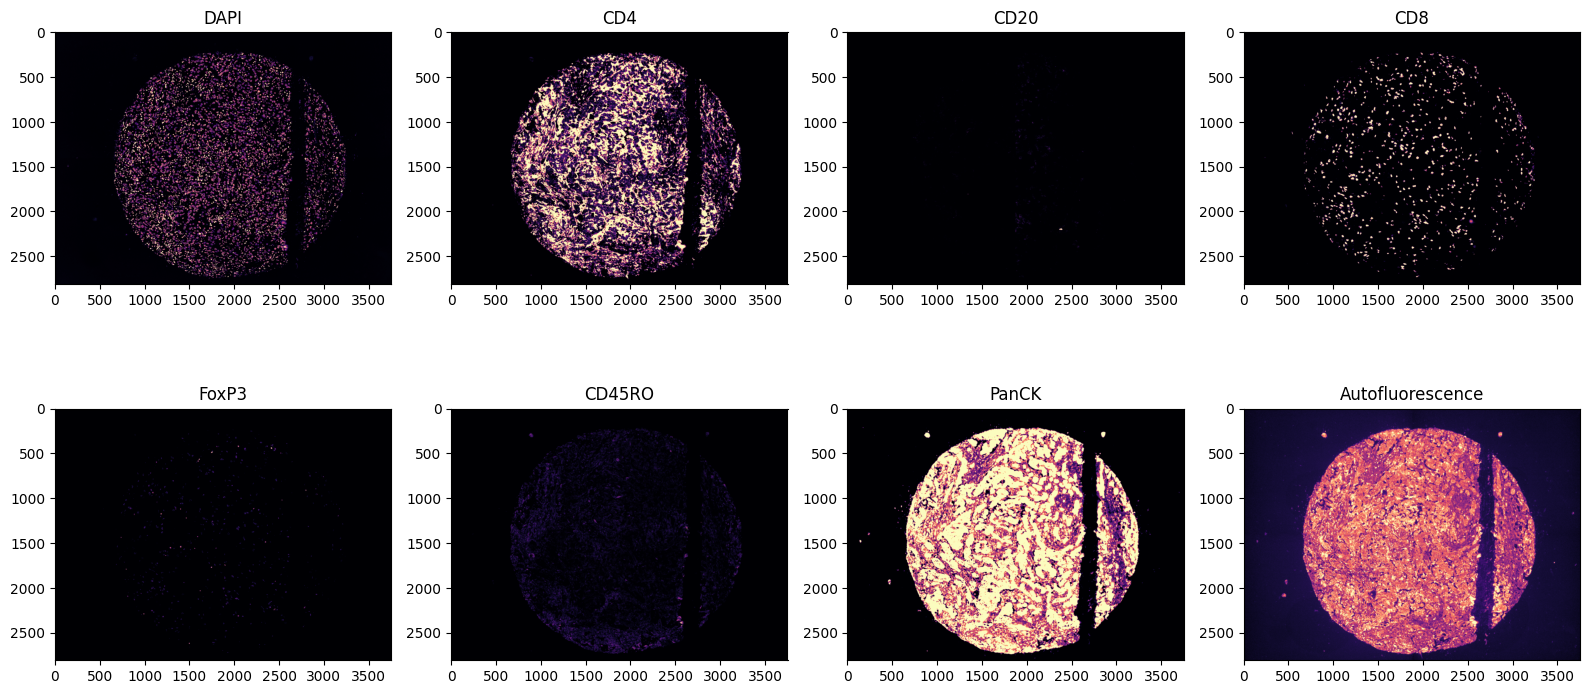

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i >= image.shape[0]:  # Use image.shape directly if image is already in a 2D format
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)
        continue

    # Clip the image based on the first channel's median and quantile, or modify this if necessary
    clipped_image = np.clip(image[i], np.median(image[0]), np.quantile(image[0], 0.99))
    
    ax.imshow(clipped_image, cmap='magma')
    ax.set_title(marker_names[i])
    ax.grid(False)

plt.tight_layout()
plt.show()

## Get attentions

In [10]:
attention_maps = attention_map_things.get_attention(image, backbone, args)

In [11]:
thattn = []
for attn in attention_maps:
    quantilecut = np.quantile(attn, 0.7)
    upperquantilecut = np.quantile(attn, 0.99)
    attn = np.clip(attn, a_min=quantilecut, a_max=upperquantilecut)
    thattn.append(attn)
thattn = np.stack(thattn, axis=0)

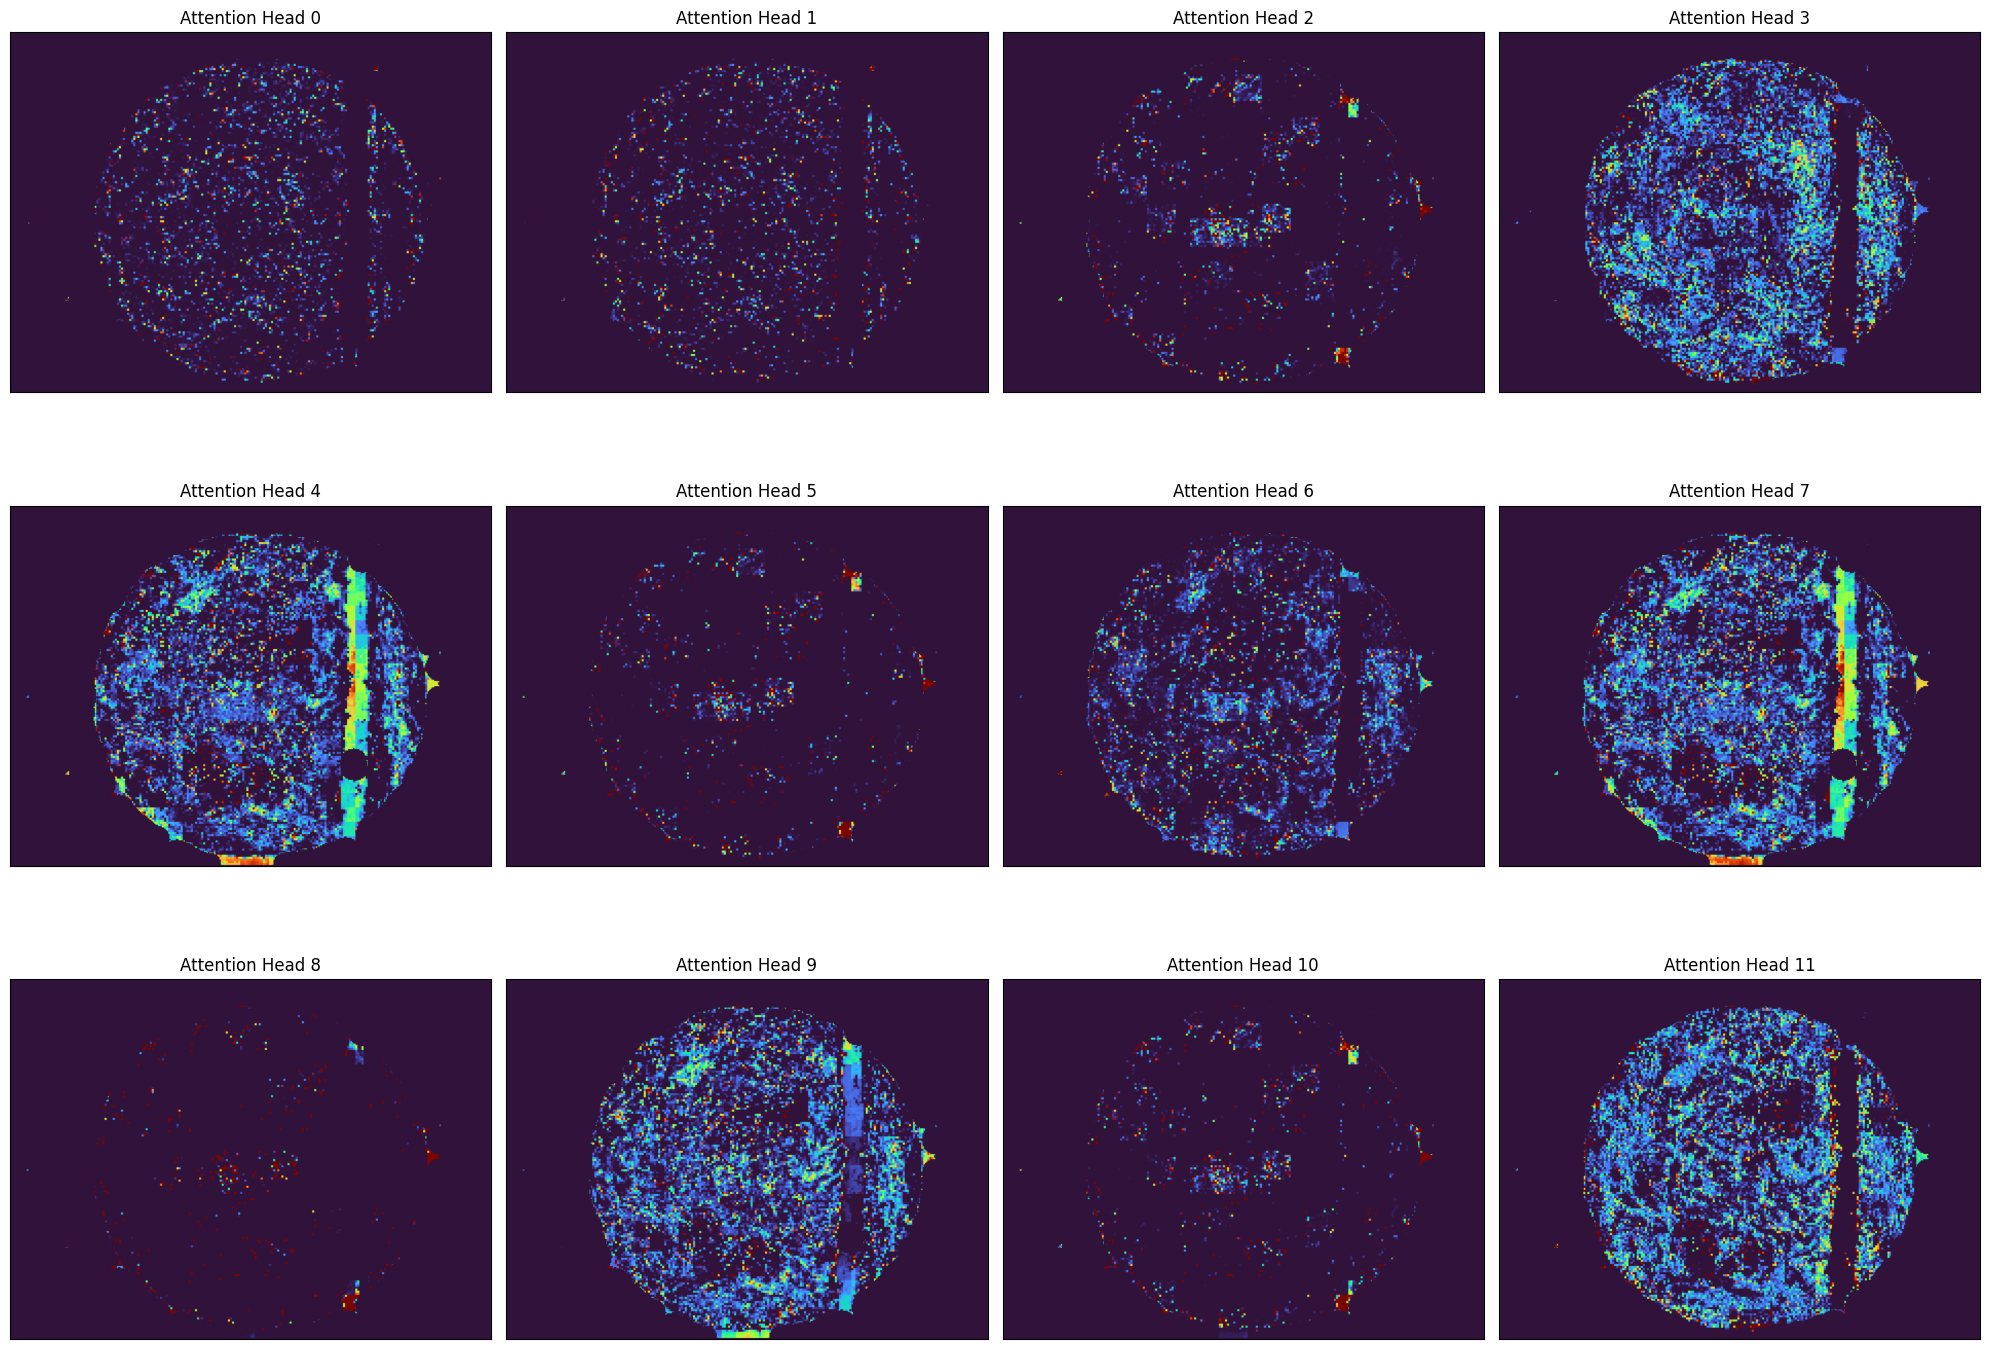

In [12]:
# Plot each attention head
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
for i, ax in enumerate(axes.flat):
    pp = (thattn[i] - thattn[i].min()) / (thattn[i].max() - thattn[i].min())
    im = ax.imshow(pp, cmap='turbo')
    ax.set_title(f'Attention Head {i}')
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    # fig.colorbar(im, ax=ax)  # Add color bar to each subplot
fig.tight_layout()
plt.show()

# Pearson correlation

In [13]:
attention_maps.shape, image.shape

((12, 2808, 3752), (8, 2808, 3752))

In [14]:
imagetn = []
for attn in image:
    lowerquantilecut, upperquantilecut = np.quantile(attn, [0.5, 0.99])
    iimgth = np.clip(attn, a_min=lowerquantilecut, a_max=upperquantilecut)
    imagetn.append(iimgth)
imagetn = np.stack(imagetn, axis=0)
thattn = []
for attn in attention_maps:
    quantilecut, upperquantilecut = np.quantile(attn, [0.8, 0.99])
    attn = np.clip(attn, a_min=quantilecut, a_max=upperquantilecut)
    thattn.append(attn)
thattn = np.stack(thattn, axis=0)

In [15]:
x = torch.cat([torch.from_numpy(imagetn.astype('int16')).flatten(1,2), 
               torch.from_numpy(thattn).flatten(1,2)
              ],
              dim=0)
x.shape

torch.Size([20, 10535616])

In [16]:
pearsoncorrs = torch.corrcoef(x)

In [17]:
pearsondf = pd.DataFrame(pearsoncorrs)
pearsondf.index = marker_names + [f'Attn {i}' for i in range(len(thattn))]
pearsondf.columns = marker_names + [f'Attn {i}' for i in range(len(thattn))]

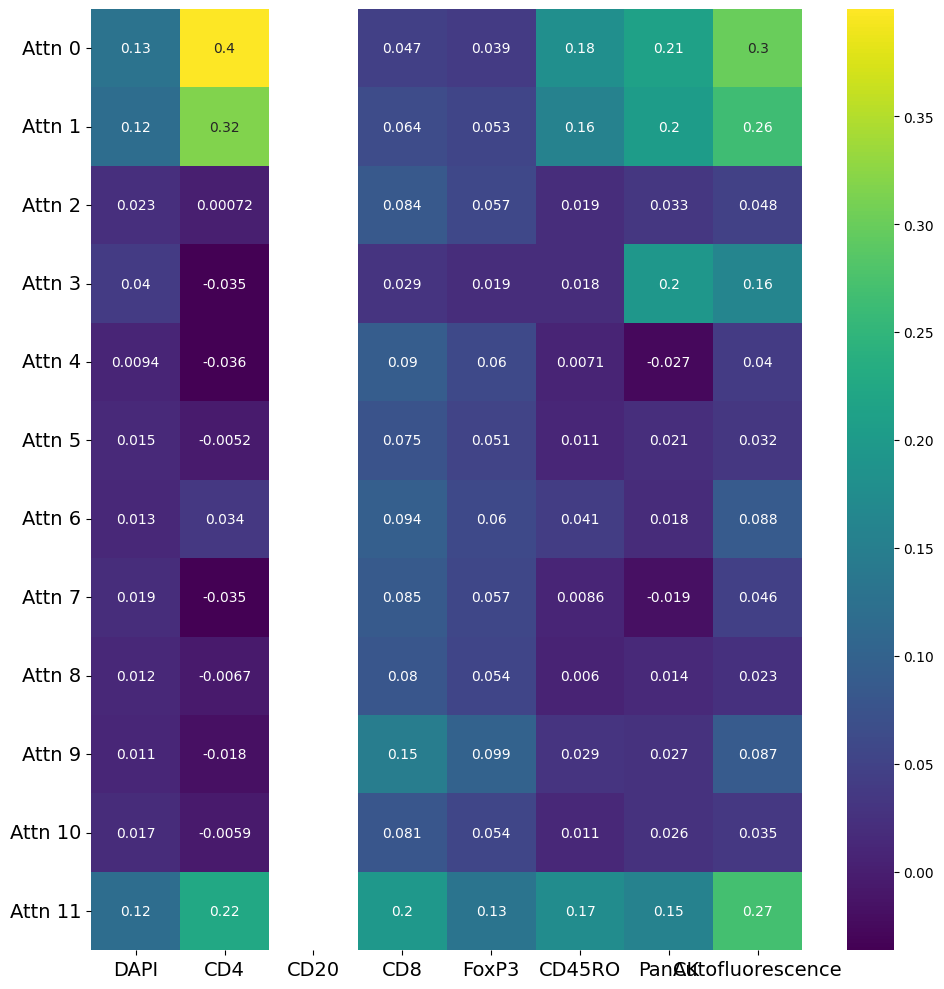

In [18]:
plt.figure(figsize=(10,10))
sns.heatmap(data=pearsondf.loc['Attn 0':'Attn 11', 'DAPI':'Autofluorescence'], cmap='viridis', annot=True)

plt.xticks(fontsize=14, rotation=0)
plt.yticks(fontsize=14, rotation=0)

plt.tight_layout()
plt.show()

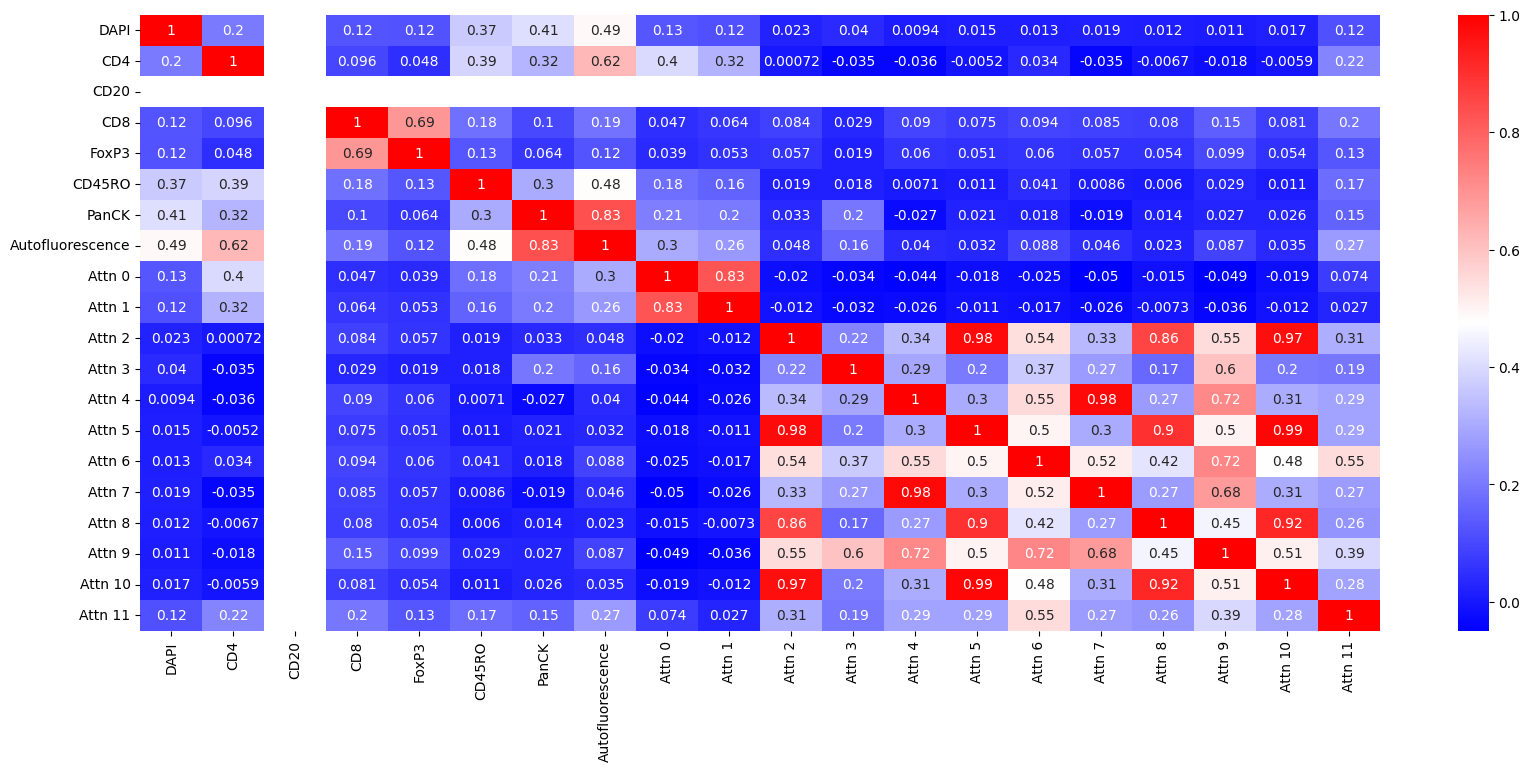

In [19]:
plt.figure(figsize=(20,8))
sns.heatmap(data=pearsondf, cmap='bwr', annot=True)
plt.show()